# 08-4 — Agent with K8s Agent-Sandbox Code Interpreter

Demonstrates a **ReActAgent** backed by `K8sSandboxCodeInterpreterTool`, which
provisions isolated Python sandbox pods via the
[`kubernetes-sigs/agent-sandbox`](https://github.com/kubernetes-sigs/agent-sandbox)
controller.

Each conversation thread gets its **own dedicated pod** created from a
`SandboxTemplate` CRD. Python state (variables, installed packages, files)
persists across calls within the same session — exactly like Claude / OpenAI
Code Interpreter. **No Firecracker, no `/dev/kvm`, and no VM pool in this path.**

### Architecture
```
Notebook  ─►  ReActAgent  ─►  K8sSandboxCodeInterpreterTool
                                           │
                               CodeInterpreterService (sync, threaded)
                                           │
                                  SandboxClient (k8s_agent_sandbox)
                                           │
                              sandbox-router-svc (Deployment)
                                           │
                             sandbox pod (from SandboxTemplate)
                             └── sandbox_runtime FastAPI :8888
                                   /ci/run  /ci/upload  /ci/reset
```

### Prerequisites
| Requirement | How to check |
|---|---|
| `OPENAI_API_KEY` | `echo $OPENAI_API_KEY` |
| K8s cluster running | `kubectl get nodes` |
| agent-sandbox controller | `kubectl get crd sandboxtemplates.extensions.agents.x-k8s.io` |
| `sandbox-router` running | `kubectl get deploy sandbox-router-deployment` |
| `python-sandbox-template` | `kubectl get sandboxtemplate python-sandbox-template` |
| `k8s_agent_sandbox` pip pkg | `python -c "import k8s_agent_sandbox"` |

**One-time cluster setup** (see Troubleshooting for details):
```bash
# 1. Install controller
kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/manifest.yaml
kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/extensions.yaml

# 2. Deploy router + template from this repo
kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandbox-router.yaml
kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandboxtemplate.code-interpreter.yaml

# 3. Build and load sandbox image from the repo root context
docker build \
  -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/Dockerfile \
  -t code-interpreter:latest \
  .
kind load docker-image code-interpreter:latest --name ai-lab
```
> Cell 2 runs a full diagnostics check and tells you exactly what's missing.
>
> Cells 6 and 7 prove the end-to-end path: first a manual Python execution, then an agent tool call using the same sandbox session.

In [1]:
import os
from ravi.configs.settings import settings

# ── Sandbox configuration ─────────────────────────────────────────────────────
SANDBOX_TEMPLATE  = os.environ.get('CI_SANDBOX_TEMPLATE', 'python-sandbox-template')
SANDBOX_NAMESPACE = os.environ.get('CI_SANDBOX_NAMESPACE', 'default')
SESSION_ID        = 'notebook-21-session'

CHAT_MODEL = settings.CHAT_MODEL
API_KEYS = {
    "openai":     settings.OPENAI_API_KEY,
    "anthropic":  settings.ANTHROPIC_API_KEY,
    "google":     settings.GEMINI_API_KEY,
    "groq":       settings.GROQ_API_KEY,
    "openrouter": settings.OPENROUTER_API_KEY,
}

print('OPENAI_API_KEY set :', bool(settings.OPENAI_API_KEY))
print('Sandbox template   :', SANDBOX_TEMPLATE)
print('Sandbox namespace  :', SANDBOX_NAMESPACE)
print('Chat model         :', CHAT_MODEL)
print('Session ID         :', SESSION_ID)

OPENAI_API_KEY set : True
Sandbox template   : python-sandbox-template
Sandbox namespace  : default
Agent model        : gpt-5.4-mini
Session ID         : notebook-21-session


## Step 1 — Diagnostics

Check that all prerequisites for the agent-sandbox controller are satisfied.

In [2]:
import subprocess

PASS = '\033[92m✔\033[0m'
FAIL = '\033[91m✘\033[0m'
WARN = '\033[93m⚠\033[0m'
failures: list[str] = []


def _run(cmd: str) -> tuple[int, str]:
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    return r.returncode, (r.stdout + r.stderr).strip()


def _parse_kubectl_rows(out: str) -> list[str]:
    """Return first column of kubectl --no-headers output, skipping 'No resources' lines."""
    return [
        line.split()[0]
        for line in out.splitlines()
        if line.strip() and not line.lower().startswith('no ')
    ]


# ── 1. kubectl ────────────────────────────────────────────────────────────────
rc, out = _run('kubectl get nodes --no-headers 2>&1')
nodes = _parse_kubectl_rows(out) if rc == 0 else []
if rc == 0 and nodes:
    print(f'{PASS} kubectl: {len(nodes)} node(s) — {nodes}')
else:
    print(f'{FAIL} kubectl unreachable: {out[:120]}')
    failures.append('kubectl')

# ── 2. agent-sandbox controller (CRD) ────────────────────────────────────────
CRD = 'sandboxtemplates.extensions.agents.x-k8s.io'
rc, out = _run(f'kubectl get crd {CRD} --no-headers 2>&1')
if rc == 0:
    print(f'{PASS} agent-sandbox CRD installed')
else:
    print(f'{FAIL} agent-sandbox CRD not found')
    print(f'      → Install: kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/manifest.yaml')
    print(f'      →          kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/extensions.yaml')
    failures.append('crd')

# ── 3. sandbox-router deployment ─────────────────────────────────────────────
rc, out = _run('kubectl get deploy sandbox-router-deployment --no-headers 2>&1')
if rc == 0 and out and not out.lower().startswith('no '):
    parts = out.split()
    ready = parts[2] if len(parts) > 2 else '?'
    print(f'{PASS} sandbox-router deployment ready={ready}')
else:
    print(f'{FAIL} sandbox-router-deployment not found')
    print(f'      → Deploy: kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandbox-router.yaml')
    failures.append('sandbox-router')

# ── 4. SandboxTemplate ───────────────────────────────────────────────────────
rc, out = _run(f'kubectl get sandboxtemplate {SANDBOX_TEMPLATE} -n {SANDBOX_NAMESPACE} --no-headers 2>&1')
if rc == 0 and out and not out.lower().startswith('no '):
    print(f'{PASS} SandboxTemplate "{SANDBOX_TEMPLATE}" found in namespace "{SANDBOX_NAMESPACE}"')
else:
    print(f'{FAIL} SandboxTemplate "{SANDBOX_TEMPLATE}" not found in namespace "{SANDBOX_NAMESPACE}"')
    print(f'      → Deploy: kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandboxtemplate.code-interpreter.yaml')
    print(f'      → Build image first: docker build -t code-interpreter:latest ...')
    failures.append('sandboxtemplate')

# ── 5. k8s_agent_sandbox Python package ──────────────────────────────────────
try:
    import k8s_agent_sandbox  # noqa: F401
    print(f'{PASS} k8s_agent_sandbox package importable')
except ImportError:
    print(f'{FAIL} k8s_agent_sandbox not installed')
    print(f'      → Install: uv add k8s_agent_sandbox')
    failures.append('k8s_agent_sandbox')

# ── Summary ───────────────────────────────────────────────────────────────────
print()
PREREQS_MET = len(failures) == 0
if PREREQS_MET:
    print(f'{PASS} All prerequisites satisfied — ready to run!')
else:
    print(f'{WARN} Missing prerequisites: {failures}')
    print('      Fix the items above, then re-run this cell.')
print(f'\nPREREQS_MET = {PREREQS_MET}')

✔ kubectl: 1 node(s) — ['ai-lab-control-plane']
✔ agent-sandbox CRD installed
✔ sandbox-router deployment ready=2
✔ SandboxTemplate "python-sandbox-template" found in namespace "default"
✔ k8s_agent_sandbox package importable

✔ All prerequisites satisfied — ready to run!

PREREQS_MET = True


## Step 2 — Imports & Agent Setup

In [3]:
from ravi.catalog.tools.code_interpreter import K8sSandboxCodeInterpreterTool
from ravi.extensions.agents.react.agent import ReActAgent
from ravi.integrations.llm.factory import create_model_client
from ravi.kernel.agent_catalog import AgentCatalog
from ravi.kernel.memory.unbounded_memory import UnboundedMemory
from ravi.extensions.context.redis_model_context import UnboundedContext
from ravi.console import Console

print('All imports OK')

All imports OK


In [4]:
# ── Build the K8sSandboxCodeInterpreterTool ───────────────────────────────────
# Each session_id maps to a dedicated sandbox pod created from the SandboxTemplate.
# The service creates the pod on first use and reuses it for subsequent calls.
ci_tool = K8sSandboxCodeInterpreterTool(
    template=SANDBOX_TEMPLATE,
    namespace=SANDBOX_NAMESPACE,
    sandbox_ready_timeout=180,   # seconds to wait for pod Ready
    request_timeout=120,         # per-request timeout
)
ci_tool.session_id = SESSION_ID

print(f'Tool         : {ci_tool.name}')
print(f'Template     : {SANDBOX_TEMPLATE}')
print(f'Namespace    : {SANDBOX_NAMESPACE}')
print(f'Session ID   : {ci_tool.session_id}')
print(f'Model        : {CHAT_MODEL}')

# ── Build the ReActAgent via catalog ─────────────────────────────────────────
catalog = AgentCatalog()
catalog.register_model('primary', create_model_client(CHAT_MODEL, api_keys=API_KEYS))
catalog.register_memory('default', UnboundedMemory())
catalog.register_context('default', UnboundedContext())
catalog.register_tool(ci_tool)

agent = ReActAgent(
    name='CodeBot',
    description='An agent that executes Python code in a sandboxed Kubernetes pod.',
    catalog=catalog,
    max_iterations=8,
    verbose=True,
)
console = Console(agent)
print(f"\nAgent '{agent.name}' ready with tool: {[t.name for t in agent.tools]}")

Tool         : code_interpreter
Template     : python-sandbox-template
Namespace    : default
Session ID   : notebook-21-session
Model        : gpt-5.4-mini

Agent 'CodeBot' ready with tool: ['code_interpreter', 'capability_search']


## Step 3 — Direct Tool Test (no LLM)

Test the `K8sSandboxCodeInterpreterTool` directly.
On first call the sandbox pod is created from the `SandboxTemplate` (may take ~10–30s).

In [7]:
import json

if not PREREQS_MET:
    print('⚠ Skipping direct execution — prerequisites not satisfied (see Cell 2).')
else:
    # Test 1: simple arithmetic + stdlib
    result = await ci_tool.execute(code='import math; print(math.pi, math.e)')
    raw = result.content[0]['text']
    print('Test 1 — math constants:')
    print(' ', raw.strip())
    print('  is_error:', result.is_error)

    # Test 2: state persistence — define a variable then retrieve it
    await ci_tool.execute(code='x = [i**2 for i in range(1, 6)]\nprint("x defined:", x)')
    result2 = await ci_tool.execute(code='print("squares:", x)')
    print('\nTest 2 — state persistence (x survives across calls):')
    print(' ', result2.content[0]['text'].strip())

    # Test 3: a package from the sandbox image
    result3 = await ci_tool.execute(code='import numpy as np; a = np.arange(5); print(a)')
    print('\nTest 3 — numpy:')
    print(' ', result3.content[0]['text'].strip())

Test 1 — math constants:
  {"success": true, "output": "3.141592653589793 2.718281828459045", "exit_code": 0}
  is_error: False

Test 2 — state persistence (x survives across calls):
  {"success": true, "output": "squares: [1, 4, 9, 16, 25]", "exit_code": 0}

Test 3 — numpy:
  {"success": true, "output": "[0 1 2 3 4]", "exit_code": 0}


## Step 4 — Agent Run

Let the `ReActAgent` decide when to invoke the code interpreter.

In [10]:
if not PREREQS_MET:
    print('⚠ Skipping agent run — prerequisites not satisfied (see Cell 2).')
else:
    await agent.reset()
    result = await console.run(
        'Compute the first 10 Fibonacci numbers, then find the sum of their squares. '
        'Show all intermediate steps with print() calls.'
    )
    print('\nFinal answer:', result.output_text)
    print('Tool calls:', result.tool_calls_by_name)

You → Compute the first 10 Fibonacci numbers, then find the sum of their squares. Show all intermediate steps with 
print() calls.

╭──────────────────────────────────────────────────── CodeBot ────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Here are the results with intermediate steps:                                                                  │
│                                                                                                                 │
│   1 First 10 Fibonacci numbers: ([0, 1, 1, 2, 3, 5, 8, 13, 21, 34])                                             │
│   2 Squares of these numbers: ([0, 1, 1, 4, 9, 25, 64, 169, 441, 1156])                                         │
│   3 Sum of the squares: (1870)                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

completed · 2 steps · 1 tool calls · 1707 tokens · 6.2s


Final answer: Here are the results with intermediate steps:

1. **First 10 Fibonacci numbers**: \([0, 1, 1, 2, 3, 5, 8, 13, 21, 34]\)

2. **Squares of these numbers**: \([0, 1, 1, 4, 9, 25, 64, 169, 441, 1156]\)

3. **Sum of the squares**: \(1870\)
Tool calls: {'code_interpreter': 1}


In [5]:
if not PREREQS_MET:
    print('⚠ Skipping agent run — prerequisites not satisfied (see Cell 2).')
else:
    await agent.reset()
    result = await console.run(
        'Using Python, generate the first 10 Fibonacci numbers, save a matplotlib '
        'line plot with markers as fibonacci_plot_agent.png, then briefly report '
        'the mean, standard deviation, and ratios of consecutive terms.'
    )
    print('\nFinal answer:', result.output_text)
    print('Tool calls:', result.tool_calls_by_name)

You → Using Python, generate the first 10 Fibonacci numbers, save a matplotlib line plot with markers as 
fibonacci_plot_agent.png, then briefly report the mean, standard deviation, and ratios of consecutive terms.

╭──────────────────────────────────────────────────── CodeBot ────────────────────────────────────────────────────╮
│                                                                                                                 │
│  Done — I generated the first 10 Fibonacci numbers and saved the plot as fibonacci_plot_agent.png.              │
│                                                                                                                 │
│  Results:                                                                                                       │
│                                                                                                                 │
│   • Fibonacci numbers: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]                                                        │
│   • Mean: 8.800                                                                                                 │
│   • Standard deviation: 10.467                                                                                  │
│                                                                                                                 │
│  Ratios of consecutive terms:                                                                                   │
│                                                                                                                 │
│   • F1/F0: undefined                                                                                            │
│   • F2/F1: 1.000000                                                                                             │
│   • F3/F2: 2.000000                                                                                             │
│   • F4/F3: 1.500000                                                                                             │
│   • F5/F4: 1.666667                                                                                             │
│   • F6/F5: 1.600000                                                                                             │
│   • F7/F6: 1.625000                                                                                             │
│   • F8/F7: 1.615385                                                                                             │
│   • F9/F8: 1.619048                                                                                             │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

completed · 2 steps · 1 tool calls · 3135 tokens · 13.0s


Final answer: Done — I generated the first 10 Fibonacci numbers and saved the plot as **`fibonacci_plot_agent.png`**.

Results:
- Fibonacci numbers: `[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]`
- Mean: **8.800**
- Standard deviation: **10.467**

Ratios of consecutive terms:
- `F1/F0`: undefined
- `F2/F1`: **1.000000**
- `F3/F2`: **2.000000**
- `F4/F3`: **1.500000**
- `F5/F4`: **1.666667**
- `F6/F5`: **1.600000**
- `F7/F6`: **1.625000**
- `F8/F7`: **1.615385**
- `F9/F8`: **1.619048**
Tool calls: {'code_interpreter': 1}


## Step 5 — Show Generated Plot

Download the matplotlib PNG created by the previous agent run and render it inline.

PNG files: ['/app/workspace/fibonacci_plot_agent.png']
Displaying: /app/workspace/fibonacci_plot_agent.png


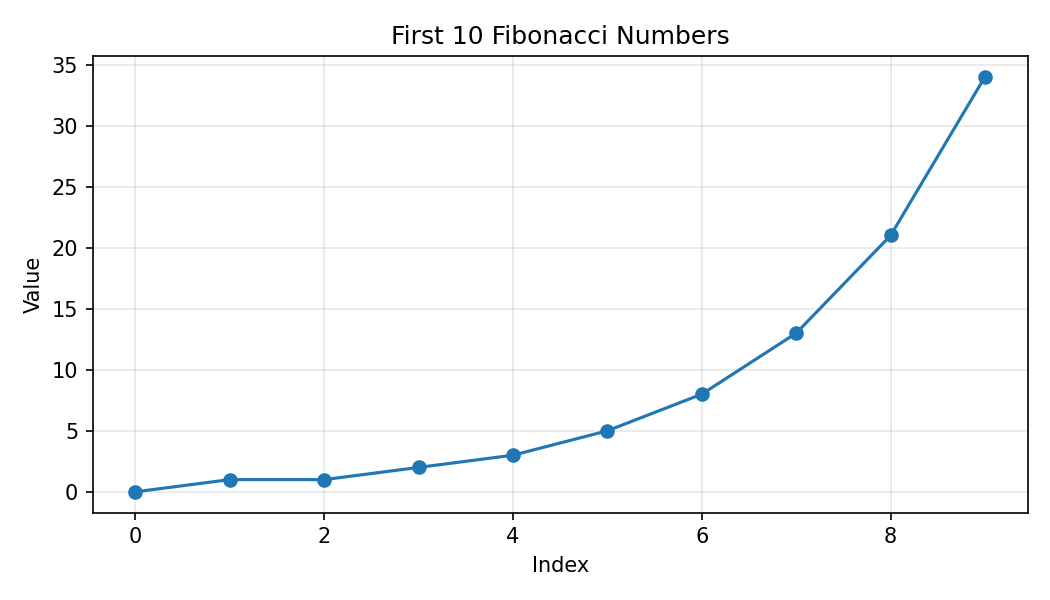

In [6]:
import asyncio
import base64
from IPython.display import Image, display

if not PREREQS_MET:
    print('⚠ Skipping — prerequisites not satisfied.')
else:
    listing = await asyncio.to_thread(ci_tool._service.list_files, SESSION_ID, '.', True)
    entries = listing.get('entries', [])
    png_paths = [
        str(entry.get('path'))
        for entry in entries
        if str(entry.get('path', '')).endswith('.png')
    ]

    if not png_paths:
        print('No PNG files found in the sandbox workspace. Re-run the previous cell.')
    else:
        target = next(
            (path for path in png_paths if path.endswith('fibonacci_plot_agent.png')),
            next((path for path in png_paths if path.endswith('fibonacci_plot.png')), png_paths[-1]),
        )
        downloaded = await asyncio.to_thread(ci_tool._service.download_file, SESSION_ID, target)
        file_data = downloaded.get('file', {})
        print('PNG files:', png_paths)
        print('Displaying:', target)
        display(Image(data=base64.b64decode(file_data['content_base64'])))

In [9]:
import io
import json
from PIL import Image
from ravi.kernel.messages.client_messages import ToolExecutionResultMessage
from ravi.kernel.messages import ImageContent

image = Image.new("RGB", (4, 4), color="red")
buffer = io.BytesIO()
image.save(buffer, format="PNG")

probe_message = ToolExecutionResultMessage(
    tool_call_id="call_probe",
    name="code_interpreter",
    content=[
        {
            "type": "text",
            "text": json.dumps({"success": True, "output": "[Generated probe.png]"}),
        }
    ],
    media=[ImageContent(data=buffer.getvalue(), media_type="image/png")],
)

instructions, serialized_items = await agent.model_client._serialize_messages([probe_message])
image_inputs = [
    content_item
    for item in serialized_items
    if item.get("type") == "message"
    for content_item in item.get("content", [])
    if content_item.get("type") == "input_image"
]

print(
    json.dumps(
        {
            "instructions": instructions,
            "serialized_item_types": [item.get("type") for item in serialized_items],
            "image_item_count": len(image_inputs),
            "uses_file_id": any(bool(item.get("file_id")) for item in image_inputs),
            "uses_data_url": any(
                isinstance(item.get("image_url"), str)
                and item["image_url"].startswith("data:")
                for item in image_inputs
            ),
            "image_inputs": image_inputs,
        },
        indent=2,
    )
)

{
  "instructions": "",
  "serialized_item_types": [
    "function_call_output",
    "message"
  ],
  "image_item_count": 1,
  "uses_file_id": true,
  "uses_data_url": false,
  "image_inputs": [
    {
      "type": "input_image",
      "file_id": "file-9mPJopv8Uk6mtoT87GVye7"
    }
  ]
}


## Step 6 — Cleanup

Terminate the sandbox pod to release cluster resources.
The `terminate_session()` call tells the agent-sandbox controller to delete the pod.

In [13]:
import asyncio

try:
    result = await asyncio.to_thread(ci_tool._service.terminate_session, SESSION_ID)
    print('Sandbox terminated:', result.get('message', result))
except Exception as exc:
    print(f'Cleanup skipped (pod may already be gone): {exc}')

print('Done.')

Sandbox terminated: Sandbox session terminated.
Done.


## Troubleshooting

| Symptom | Fix |
|---|---|
| `agent-sandbox CRD not found` | Install controller: `kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/manifest.yaml` + `extensions.yaml` |
| `sandbox-router-deployment not found` | `kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandbox-router.yaml` |
| `SandboxTemplate not found` | `kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandboxtemplate.code-interpreter.yaml` |
| `k8s_agent_sandbox not installed` | `uv add k8s_agent_sandbox` |
| `POST /ci/run` returns 404 | Rebuild the sandbox image from the repo root context, reload it into kind, then recreate the sandbox pod |
| `ImagePullBackOff` on sandbox pod | Build + load image: see below |
| Pod stuck `Pending` | Check node resources: `kubectl describe pod <sandbox-pod>` |
| Sandbox ready timeout | Increase `sandbox_ready_timeout` in Cell 4, or check pod logs |

### One-time cluster setup

```bash
# 1. Install the agent-sandbox controller and extensions
kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/manifest.yaml
kubectl apply -f https://github.com/kubernetes-sigs/agent-sandbox/releases/download/v0.4.5/extensions.yaml

# 2. Deploy the sandbox router and SandboxTemplate from this repo
kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandbox-router.yaml
kubectl apply -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/sandboxtemplate.code-interpreter.yaml

# 3. Build the sandbox runtime image and load into kind
docker build \
  -f src/ravi/catalog/tools/code_interpreter/code_interpreter/agent-sandbox/Dockerfile \
  -t code-interpreter:latest \
  .
kind load docker-image code-interpreter:latest --name ai-lab

# 4. Verify everything is up
kubectl get deploy,svc | grep sandbox
kubectl get sandboxtemplate python-sandbox-template
```

### Quick debug commands
```bash
# Find the current sandbox session pod
kubectl get pods -n default | grep sandbox-claim

# Tail logs from a running sandbox pod
kubectl logs <sandbox-pod-name> -f

# Verify the runtime API inside the pod
kubectl exec -n default <sandbox-pod-name> -- python -c "import urllib.request; print(urllib.request.urlopen('http://127.0.0.1:8888/').read().decode())"

# Recreate a stuck sandbox pod
kubectl delete pod <sandbox-pod-name>
```

> This path uses **one pod per session**, not a Firecracker VM pool.
> If you need the Firecracker-backed pool model, use `CodeInterpreterTool` instead of `K8sSandboxCodeInterpreterTool`.